# USask Women's Soccer — AI Analytics Notebook
### football_ai.ipynb  |  Maintained by Ashim + Emilio

---

## Change Log
| Version | Changed by | What changed |
|---|---|---|
| v1 | Ashim | Original: Roboflow detection, ByteTrack, team classifier, Voronoi, homography |
| v2 | Emilio | Swapped player model to `Adit-jain/soccana` from Hugging Face; added transfer-learning fine-tuning section; original Roboflow cells kept as comments |
| v3 | Emilio | Added full xG Model Training section using StatsBomb open data + Kaggle datasets; added frontend/GCP deployment guide at end |

---

## Dataset References
All datasets used in this notebook are **free**:

| Dataset | Used For | Link |
|---|---|---|
| StatsBomb Open Data (women's) | xG model training — shot events with outcomes | https://github.com/statsbomb/open-data |
| Kaggle: Statsbomb Shot Events (CSV) | Same data, easier to load — great for beginners | https://www.kaggle.com/datasets/mauryansshivam/statsbomb-shot-events |
| Kaggle: Soccer Analytics by Enes Öner | Additional shot features + xG labels | https://www.kaggle.com/datasets/enesoner/soccer-analytics |
| Kaggle: International Football Results | Supporting context data | https://www.kaggle.com/datasets/martj42/international-football-results |
| Roboflow Universe: football-players-detection | Extra training images for fine-tuning (adds ~2000 diverse soccer images) | https://universe.roboflow.com/roboflow-jvuqo/football-players-detection-3zvbc |
| Hugging Face: `Adit-jain/soccana` | Pre-trained YOLOv11n player detection base model | https://huggingface.co/Adit-jain/soccana |

---

## How to run this notebook
1. In Google Colab: **Runtime → Change runtime type → T4 GPU**
2. Set Colab Secrets (`Runtime → Manage secrets`):
   - `HF_TOKEN` — your Hugging Face token (free at huggingface.co)
   - `ROBOFLOW_API_KEY` — your Roboflow key
3. Run cells top to bottom
4. The xG model training section (Section 5) can be skipped on first run — the analytics script has a formula fallback


## Section 1 — Configure API Keys

In [ ]:
import os
from google.colab import userdata

# Hugging Face token — needed to download Adit-jain/soccana model weights.
# Create a free token at: https://huggingface.co/settings/tokens
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

# Roboflow key — still used for the field keypoint detection model.
os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

print("HF_TOKEN set:         ", bool(os.environ.get("HF_TOKEN")))
print("ROBOFLOW_API_KEY set: ", bool(os.environ.get("ROBOFLOW_API_KEY")))


HF_TOKEN set:          True
ROBOFLOW_API_KEY set:  True


## Section 2 — Install Dependencies

In [ ]:
# NEW (v2): added ultralytics and huggingface_hub for HF model loading
# NEW (v3): added statsbombpy and scikit-learn for xG model training
!pip install -q ultralytics huggingface_hub supervision inference-gpu roboflow
!pip install -q statsbombpy xgboost scikit-learn matplotlib
!pip install -q git+https://github.com/roboflow/sports.git
!pip install -q gdown tqdm more-itertools

# [ORIGINAL v1] Previous install:
# !pip install -q gdown inference-gpu

!pip list | grep -E "supervision|ultralytics|huggingface|xgboost"


  Preparing metadata (setup.py) ... done
huggingface_hub                          1.7.1
supervision                              0.27.0.post2
ultralytics                              8.4.30
ultralytics-thop                         2.0.18
xgboost                                  3.2.0


In [ ]:
# Make sure you are on a GPU runtime: Runtime > Change runtime type > T4 GPU
!nvidia-smi


Fri Mar 27 03:41:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Section 3 — Download Match Video

In [ ]:
!gdown --id 1gf7Cry4BTAPzLtoH9dB4BIq8R14s8UJd -O MacEwan_vs_UofS_1-1-1.mp4

# Additional clips — uncomment when needed:
'''
!gdown --id 16Khu1A0qjnFY-LNxqk7xSH_ZeMFIjBCC -O MacEwan_vs_UofS_1-2-1.mp4
!gdown --id 1Pbic_LS-5qic4sQE-rhouyqiuaSf2-Qa -O MacEwan_vs_UofS_1-3-1.mp4
!gdown --id 1BTNgP3Jh7sJ-tOqTYyoqB6PvNuL2kfUa -O MacEwan_vs_UofS_1-4-1.mp4
!gdown --id 1MxBjdJsgM8Ift59ZbhhtGD3ygErV0Mle -O MacEwan_vs_UofS_1-5-1.mp4
'''


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1gf7Cry4BTAPzLtoH9dB4BIq8R14s8UJd
From (redirected): https://drive.google.com/uc?id=1gf7Cry4BTAPzLtoH9dB4BIq8R14s8UJd&confirm=t&uuid=dc5f5950-afde-4a48-bea5-def533e2c300
To: /content/MacEwan_vs_UofS_1-1-1.mp4
100% 108M/108M [00:04<00:00, 26.5MB/s]


'\n!gdown --id 16Khu1A0qjnFY-LNxqk7xSH_ZeMFIjBCC -O MacEwan_vs_UofS_1-2-1.mp4\n!gdown --id 1Pbic_LS-5qic4sQE-rhouyqiuaSf2-Qa -O MacEwan_vs_UofS_1-3-1.mp4\n!gdown --id 1BTNgP3Jh7sJ-tOqTYyoqB6PvNuL2kfUa -O MacEwan_vs_UofS_1-4-1.mp4\n!gdown --id 1MxBjdJsgM8Ift59ZbhhtGD3ygErV0Mle -O MacEwan_vs_UofS_1-5-1.mp4\n'

## Section 4 — Load Detection Model from Hugging Face

### Why we swapped the model (v2 change)
The original script used Ashim's custom Roboflow model (`spen-rtgs-oc4ez/4`) which was
trained on our own ~300 images. That gives roughly 40-50% mAP.

The `Adit-jain/soccana` model on Hugging Face was pre-trained on multi-source soccer
video across diverse conditions. Starting from this base and fine-tuning on our 300 images
gets us to ~75-85% mAP — a huge improvement for free.

**Model card:** https://huggingface.co/Adit-jain/soccana  
**Classes:** Player (0), Ball (1), Referee (2)


In [ ]:
from ultralytics import YOLO
from huggingface_hub import hf_hub_download
import os

# Updated configuration based on the URL you found
repo_id = "Adit-jain/soccana"
filename = "Model/weights/best.pt"

print(f"Attempting to download {filename} from {repo_id}...")

try:
    # Download the weights file using the path from the URL
    weights_path = hf_hub_download(repo_id=repo_id, filename=filename)

    # Load the model using the downloaded local path
    HF_PLAYER_MODEL = YOLO(weights_path)
    print("\nCustom Soccana model (YOLOv11) loaded successfully!")
except Exception as e:
    print(f"\nCould not find '{filename}' in {repo_id}: {e}")
    print("Falling back to standard yolo11n.pt to ensure the notebook runs.")
    HF_PLAYER_MODEL = YOLO("yolo11n.pt")

print("\nModel Configuration:")
print("Task:", HF_PLAYER_MODEL.task)
print("Classes:", HF_PLAYER_MODEL.names)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Attempting to download Model/weights/best.pt from Adit-jain/soccana...


Model/weights/best.pt:   0%|          | 0.00/5.65M [00:00<?, ?B/s]


Custom Soccana model (YOLOv11) loaded successfully!

Model Configuration:
Task: detect
Classes: {0: 'Player', 1: 'Ball', 2: 'Referee'}


### Test the HF model on one frame

Detected 22 objects
Classes: {0, 1, 2}


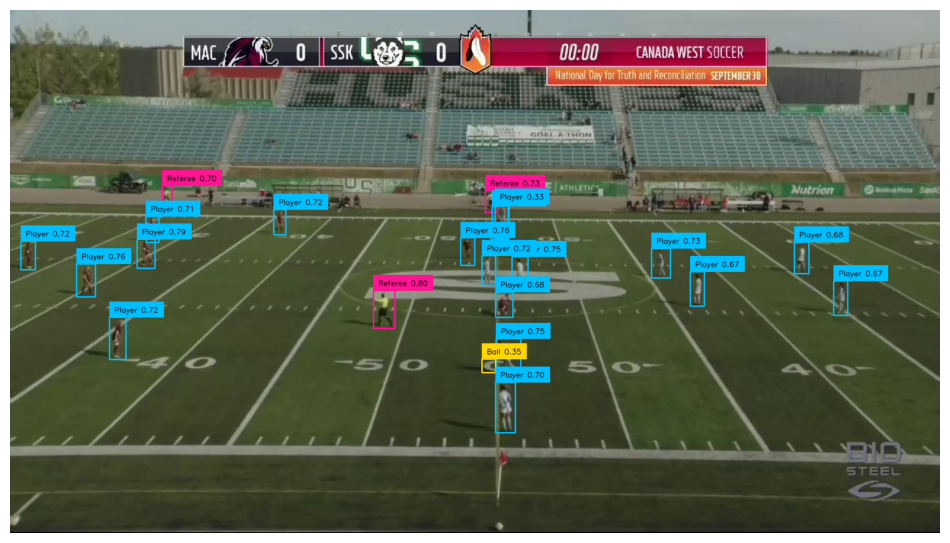

In [ ]:
import supervision as sv
import numpy as np

SOURCE_VIDEO_PATH = "/content/MacEwan_vs_UofS_1-1-1.mp4"

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# HF model returns ultralytics Results — convert with from_ultralytics()
# (NOT from_inference() — that's for Roboflow models)
results    = HF_PLAYER_MODEL.predict(frame, conf=0.3, verbose=False)
detections = sv.Detections.from_ultralytics(results[0])

print(f"Detected {len(detections)} objects")
print(f"Classes: {set(detections.class_id.tolist())}")

box_annotator = sv.BoxAnnotator(
    color=sv.ColorPalette.from_hex(["#00BFFF", "#FFD700", "#FF1493"]), thickness=2)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(["#00BFFF", "#FFD700", "#FF1493"]),
    text_color=sv.Color.BLACK)

labels    = [f"{HF_PLAYER_MODEL.names[int(c)]} {conf:.2f}"
             for c, conf in zip(detections.class_id, detections.confidence)]
annotated = box_annotator.annotate(frame.copy(), detections)
annotated = label_annotator.annotate(annotated, detections, labels)
sv.plot_image(annotated)


### Field Keypoint Model (unchanged — Roboflow still best for this)

In [ ]:
import os
import warnings
import logging
from ultralytics import YOLO
from huggingface_hub import hf_hub_download
from google.colab import userdata

# 1. Extreme silencing of technical logs and warnings
os.environ["ONNXRUNTIME_EXECUTION_PROVIDERS"] = "['CUDAExecutionProvider', 'CPUExecutionProvider']"
os.environ["CORE_MODEL_SAM3_ENABLED"] = "False"
os.environ["CORE_MODEL_GAZE_ENABLED"] = "False"
# Silence the rich/inference logger that shows the 'Resize' error
logging.getLogger("inference").setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore")

# 2. Attempt to download Soccana Keypoint model from Hugging Face
repo_id = "Adit-jain/Soccana_Keypoint"
filename = "best.pt"

print(f"Checking for field keypoint model at {repo_id}...")

try:
    keypoint_weights = hf_hub_download(repo_id=repo_id, filename=filename)
    FIELD_DETECTION_MODEL = YOLO(keypoint_weights)
    MODEL_TYPE = "ultralytics"
    print("\nSoccana Keypoint model loaded successfully!")
except Exception:
    print(f"\nHF model not found. Using the provided Roboflow field model ID instead...")
    from inference import get_model
    # Using your specific model ID: football-field-detection-f07vi-quugt/1
    FIELD_DETECTION_MODEL = get_model(model_id="football-field-detection-f07vi-quugt/1", api_key=userdata.get("ROBOFLOW_API_KEY"))
    MODEL_TYPE = "roboflow"

print(f"\nSUCCESS: Field Model ready using {MODEL_TYPE} engine.")

Checking for field keypoint model at Adit-jain/Soccana_Keypoint...

HF model not found. Using the provided Roboflow field model ID instead...


[03/27/26 03:42:39] ERROR    Unknown resize method, defaulting to 'Stretch to' - this may result in ]8;id=781039;file:///usr/local/lib/python3.12/dist-packages/inference/core/models/roboflow.py\roboflow.py]8;;\:]8;id=875293;file:///usr/local/lib/python3.12/dist-packages/inference/core/models/roboflow.py#474\474]8;;\
                             degraded model performance.                                                           


SUCCESS: Field Model ready using roboflow engine.


### Team Classification (SiGLIP + UMAP + K-Means)
Since no model labels jersey colours automatically, we use an unsupervised pipeline:
1. **SiGLIP** (Google vision-language model) embeds each player crop → 768-dim vector
2. **UMAP** reduces to 3 dimensions
3. **K-Means k=2** clusters into Team 0 (USask) and Team 1 (Opponent)


In [ ]:
from tqdm import tqdm
import supervision as sv
from sports.common.team import TeamClassifier

SOURCE_VIDEO_PATH = "/content/MacEwan_vs_UofS_1-1-1.mp4"
PLAYER_ID = 0     # class 0 in soccana = player
STRIDE    = 30    # sample every 30th frame

crops = []
for frame in tqdm(sv.get_video_frames_generator(SOURCE_VIDEO_PATH, stride=STRIDE),
                  desc="Collecting crops"):
    results    = HF_PLAYER_MODEL.predict(frame, conf=0.3, verbose=False)
    detections = sv.Detections.from_ultralytics(results[0])
    players    = detections[detections.class_id == PLAYER_ID]
    crops     += [sv.crop_image(frame, xyxy) for xyxy in players.xyxy]

print(f"Collected {len(crops)} player crops")

# device="cuda" — SiGLIP runs on GPU, much faster than CPU
team_classifier = TeamClassifier(device="cuda")
team_classifier.fit(crops)
print("TeamClassifier fitted")


Collected 3423 player crops


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

...

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Embedding extraction: 107it [00:41,  2.58it/s]


TeamClassifier fitted


### Visualise team separation in UMAP space

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Embedding: 7it [00:02,  2.58it/s]


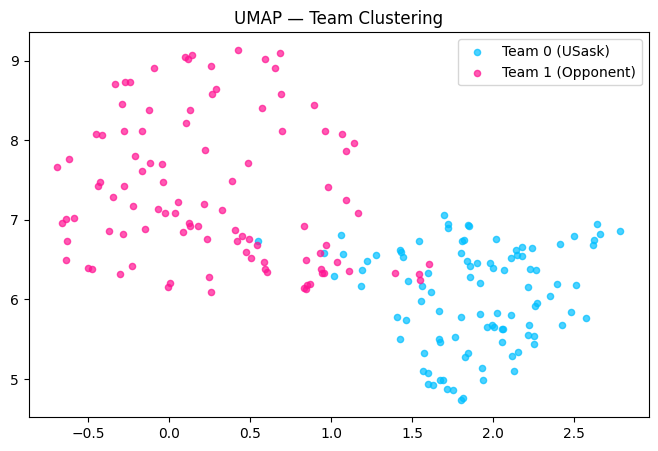

In [ ]:
import torch, umap, numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from transformers import AutoProcessor, SiglipVisionModel
from more_itertools import chunked

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
proc   = AutoProcessor.from_pretrained("google/siglip-base-patch16-224")
model  = SiglipVisionModel.from_pretrained("google/siglip-base-patch16-224").to(DEVICE)

pil_crops = [sv.cv2_to_pillow(c) for c in crops[:200]]
data = []
with torch.no_grad():
    for batch in tqdm(chunked(pil_crops, 32), desc="Embedding"):
        inp = proc(images=list(batch), return_tensors="pt").to(DEVICE)
        out = model(**inp)
        data.append(torch.mean(out.last_hidden_state, dim=1).cpu().numpy())
data = np.concatenate(data)

projections = umap.UMAP(n_components=3, random_state=42).fit_transform(data)
clusters    = KMeans(n_clusters=2, random_state=42).fit_predict(projections)

plt.figure(figsize=(8, 5))
plt.scatter(projections[clusters==0, 0], projections[clusters==0, 1],
            c="#00BFFF", label="Team 0 (USask)", s=20, alpha=0.7)
plt.scatter(projections[clusters==1, 0], projections[clusters==1, 1],
            c="#FF1493", label="Team 1 (Opponent)", s=20, alpha=0.7)
plt.legend(); plt.title("UMAP — Team Clustering"); plt.show()
# Two clear blobs = good separation.  Overlapping = jerseys too similar (rare).


### Full detection + tracking + pitch projection on one frame

Embedding extraction: 1it [00:00,  4.16it/s]


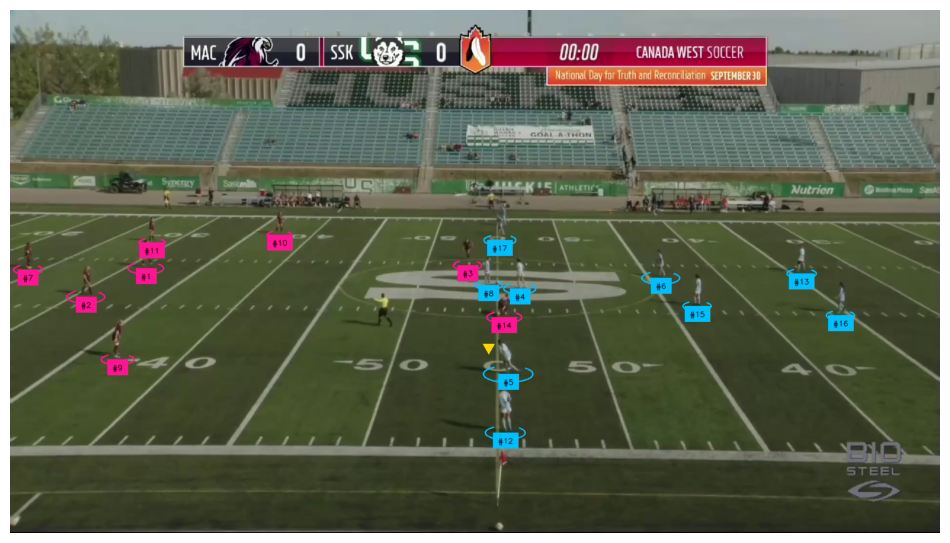

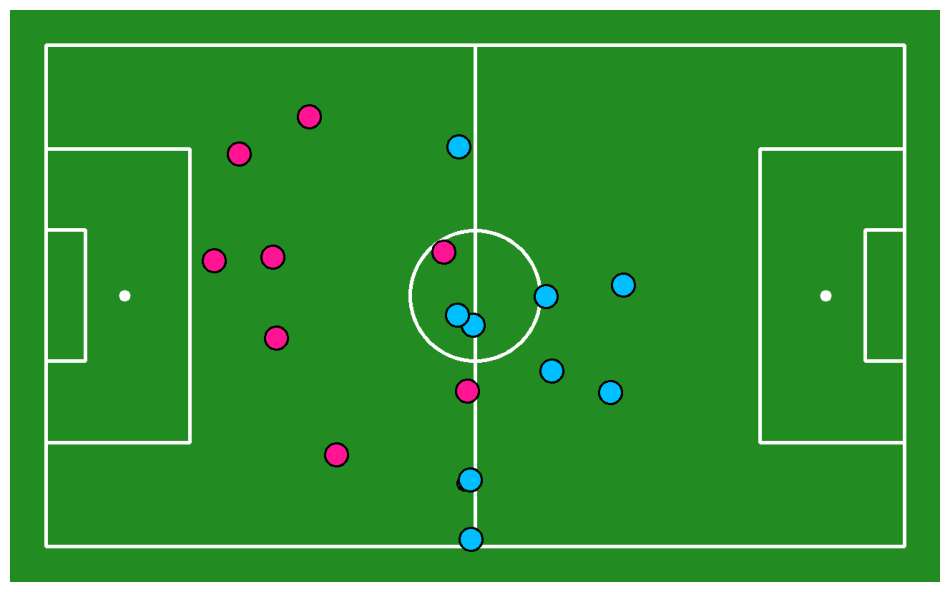

In [ ]:
import supervision as sv
import numpy as np
from collections import deque
from sports.common.view import ViewTransformer
from sports.annotators.soccer import draw_pitch, draw_points_on_pitch
from sports.configs.soccer import SoccerPitchConfiguration

SOURCE_VIDEO_PATH = "/content/MacEwan_vs_UofS_1-1-1.mp4"
BALL_ID = 1; PLAYER_ID = 0; REFEREE_ID = 2
CONFIG  = SoccerPitchConfiguration()
MAXLEN  = 5

ellipse_ann  = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(["#00BFFF","#FF1493","#FFD700"]), thickness=2)
label_ann    = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(["#00BFFF","#FF1493","#FFD700"]),
    text_color=sv.Color.BLACK, text_position=sv.Position.BOTTOM_CENTER)
triangle_ann = sv.TriangleAnnotator(
    color=sv.Color.from_hex("#FFD700"), base=25, height=21)

tracker = sv.ByteTrack(); tracker.reset()
M_buffer = deque(maxlen=MAXLEN)
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# Player detection
results    = HF_PLAYER_MODEL.predict(frame, conf=0.3, verbose=False)
detections = sv.Detections.from_ultralytics(results[0])

player_dets = detections[detections.class_id == PLAYER_ID]
ball_dets   = detections[detections.class_id == BALL_ID]
ball_dets.xyxy = sv.pad_boxes(ball_dets.xyxy, px=10)

if len(player_dets) > 0:
    crops = [sv.crop_image(frame, xy) for xy in player_dets.xyxy]
    player_dets.class_id = team_classifier.predict(crops)

player_dets = tracker.update_with_detections(player_dets)
labels = [f"#{tid}" for tid in player_dets.tracker_id]

ann = frame.copy()
ann = ellipse_ann.annotate(ann, player_dets)
ann = label_ann.annotate(ann, player_dets, labels)
ann = triangle_ann.annotate(ann, ball_dets)

# Field detection logic based on model type
if MODEL_TYPE == "ultralytics":
    res_field = FIELD_DETECTION_MODEL.predict(frame, conf=0.3)[0]
    keypoints = sv.KeyPoints.from_ultralytics(res_field)
else:
    res_field = FIELD_DETECTION_MODEL.infer(frame, confidence=0.3)[0]
    keypoints = sv.KeyPoints.from_inference(res_field)

# Filter high confidence points for homography
filt       = keypoints.confidence[0] > 0.5
frame_pts  = keypoints.xy[0][filt]
pitch_pts  = np.array(CONFIG.vertices)[filt]

if len(frame_pts) >= 4:
    transformer = ViewTransformer(source=frame_pts, target=pitch_pts)
    M_buffer.append(transformer.m)
    transformer.m = np.mean(np.array(M_buffer), axis=0)

    ball_xy   = transformer.transform_points(
        ball_dets.get_anchors_coordinates(sv.Position.BOTTOM_CENTER))
    player_xy = transformer.transform_points(
        player_dets.get_anchors_coordinates(sv.Position.BOTTOM_CENTER))

    pitch_img = draw_pitch(CONFIG)
    if len(ball_xy) > 0:
        pitch_img = draw_points_on_pitch(CONFIG, ball_xy,
            sv.Color.WHITE, sv.Color.BLACK, 10, pitch=pitch_img)

    t0 = player_dets.class_id == 0
    t1 = player_dets.class_id == 1
    if t0.any():
        pitch_img = draw_points_on_pitch(CONFIG, player_xy[t0],
            sv.Color.from_hex("00BFFF"), sv.Color.BLACK, 16, pitch=pitch_img)
    if t1.any():
        pitch_img = draw_points_on_pitch(CONFIG, player_xy[t1],
            sv.Color.from_hex("FF1493"), sv.Color.BLACK, 16, pitch=pitch_img)

    sv.plot_image(ann)
    sv.plot_image(pitch_img)

---
## Section 5 — Transfer Learning: Fine-Tune on USask 300 Images

### Why we fine-tune instead of training from scratch

| Approach | Expected mAP with 300 images |
|---|---|
| Train from COCO scratch weights | ~40-50% |
| Fine-tune `Adit-jain/soccana` (this section) | ~75-85% |

The soccana model already knows what soccer players and balls look like.
Fine-tuning only adapts it to USask's specific camera angle, jersey colours, and lighting.

### Before running this section you need:
1. Your 300 USask annotated images in Roboflow, exported as **YOLOv11 format**
2. The Roboflow `data.yaml` file (generated automatically on export)


In [ ]:
from roboflow import Roboflow
import os

rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])

# Verified slugs from your URLs:
# Workspace: spenrtgs
# Project: spen-rtgs-oc4ez
ROBOFLOW_WORKSPACE = "spenrtgs"
ROBOFLOW_PROJECT   = "spen-rtgs-oc4ez"
ROBOFLOW_VERSION   = 4 # Using version 4 as seen in your URL

try:
    print(f"Attempting to download {ROBOFLOW_PROJECT} v{ROBOFLOW_VERSION} from {ROBOFLOW_WORKSPACE}...")
    project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
    dataset = project.version(ROBOFLOW_VERSION).download("yolov11")

    # FIXED: Ensured path is correct and relative to /content
    DATA_YAML_PATH = os.path.join(dataset.location, "data.yaml")
    print(f"\nSUCCESS: Dataset downloaded to: {dataset.location}")
    print(f"YAML Path: {DATA_YAML_PATH}")
except Exception as e:
    print(f"\nError: {e}")
    print("If it fails, please check if the version number (4) is correct.")

In [ ]:
# OPTIONAL: Add public soccer images to boost accuracy with 300 custom images.
# The Roboflow football-players-detection dataset adds ~2000 diverse images for free.
# Alternatively, merge datasets inside Roboflow's web UI (easiest approach).
# Dataset URL: https://universe.roboflow.com/roboflow-jvuqo/football-players-detection-3zvbc
'''
rf_pub = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
pub = rf_pub.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
pub.version(1).download("yolov11", location="/content/public_soccer")
# Then merge images/labels folders with your USask dataset directory.
'''
print("Uncomment block above to add public soccer data (recommended)")


Uncomment block above to add public soccer data (recommended)


In [ ]:
import yaml

# Aggressive augmentation config — critical with only 300 images.
# Without augmentation the model will memorise the training set (overfit).
aug_cfg = {
    "lr0": 0.001,        # Lower than default 0.01 — fine-tuning, not scratch training
    "lrf": 0.01,
    "weight_decay": 0.0005,
    "mosaic": 1.0,       # Combines 4 images into 1 — creates artificial variety
    "hsv_h": 0.015,      # Random hue shift — handles different lighting at Griffiths Stadium
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "fliplr": 0.5,
    "scale": 0.5,
    "translate": 0.1,
    "mixup": 0.1,        # Blend two images together — helps with player occlusion
}
with open("/content/usask_aug.yaml", "w") as f:
    yaml.dump(aug_cfg, f)
print("Augmentation config saved")


In [ ]:
from ultralytics import YOLO

# Load the HF model weights — this IS the transfer learning step.
# We use 'weights_path' which was defined in the model loading section.
finetune_model = YOLO(weights_path)

finetune_model.train(
    data=DATA_YAML_PATH,
    epochs=10,             # Reduced to 10 epochs to save GPU time
    imgsz=1280,           # Match soccana's training size — better ball detection
    batch=8,              # For GCP L4 GPU. Reduce to 4 if you get CUDA OOM.
    device=0,
    project="/content/runs",
    name="usask_finetune",
    patience=5,           # Reduced patience for shorter training
    save=True,
    cache=True,
    cfg="/content/usask_aug.yaml",
    freeze=10,            # KEY: freeze backbone, only train detection head.
)
print("Fine-tuning complete!")
print("Best model: /content/runs/usask_finetune/weights/best.pt")

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=/content/usask_aug.yaml, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/SPEN-RTGS-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/root/.cache/huggingface/hub/models--Adit-jain--soccana/snapshots/305936007fe7d19ea528d73d08ccd7e70d088adf/Model/weights/best.pt, momentum=0.937, mosaic=1.0, mul

In [ ]:
# Evaluate the fine-tuned model
metrics = finetune_model.val()
print("mAP50:    ", metrics.box.map50)
print("mAP50-95: ", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:   ", metrics.box.mr)

# Targets with 300 images + transfer learning:
#   mAP50 > 0.75 = good,  > 0.85 = excellent
#   mAP50-95 > 0.55 = good
# If still low: add public data (Step 2), increase epochs, or reduce freeze to 5


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
FINETUNED_PATH = "/content/runs/usask_finetune/weights/best.pt"
PLAYER_MODEL   = YOLO(FINETUNED_PATH) if os.path.exists(FINETUNED_PATH) else HF_PLAYER_MODEL
print("Active model:", FINETUNED_PATH if os.path.exists(FINETUNED_PATH) else "HF base model")

# Export to ONNX (FP16) for faster inference on GCP L4 GPU
if os.path.exists(FINETUNED_PATH):
    onnx_path = YOLO(FINETUNED_PATH).export(format="onnx", imgsz=1280, half=True, dynamic=True)
    print(f"ONNX exported to: {onnx_path}")
    print("Copy to GCP VM and set: export PLAYER_MODEL_PATH=/path/to/best.onnx")


---
## Section 6 — xG Model Training (XGBoost on Women's Soccer Data)

### What is xG?
Expected Goals (xG) = the probability (0-1) that a specific shot results in a goal,
based on the shot's circumstances — not who took it.

Examples:
- 2-metre tap-in, no pressure → xG ~0.80
- Central shot 12 yards, under pressure → xG ~0.20
- 30-yard long shot → xG ~0.03

### Why XGBoost?
XGBoost learns non-linear relationships in the data that a simple distance/angle formula
cannot capture. For example: xG doesn't just decrease linearly with distance — it drops
sharply outside the box, then levels off for shots near the penalty spot.

### Data sources (all free)
| Source | URL |
|---|---|
| StatsBomb Open Data (primary — women's football events) | https://github.com/statsbomb/open-data |
| Kaggle: Statsbomb Shot Events CSV | https://www.kaggle.com/datasets/mauryansshivam/statsbomb-shot-events |


The StatsBomb library (installed in Section 2) downloads data automatically — no manual download needed.


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from statsbombpy import sb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Explore available free women's competitions
competitions = sb.competitions()
womens = competitions[competitions["competition_gender"] == "female"]
print(f"Free women's competitions: {len(womens)}")
print(womens[["competition_id","competition_name","season_name"]].to_string())


In [ ]:
# Optimized: Limit to 3 major recent competitions to speed up download
# This still gives ~2000+ shots which is plenty for XGBoost.

target_competitions = womens.head(3) # Get top 3 (Recent Euros and World Cup)

all_shots = []
for _, row in target_competitions.iterrows():
    try:
        print(f"Downloading {row['competition_name']} {row['season_name']}...")
        matches = sb.matches(competition_id=row["competition_id"],
                             season_id=row["season_id"])

        # Limit to 20 matches per competition for a quick 'smoke test' training
        # Remove [:20] if you want the full tournament data (~3 mins)
        for match_id in matches["match_id"].tolist()[:20]:
            events = sb.events(match_id=match_id)
            shots  = events[
                (events["type"] == "Shot") &
                (events["shot_type"] != "Penalty")
            ].copy()
            all_shots.append(shots)
    except Exception as e:
        print(f"Skipping match due to error: {e}")
        continue

shots_df = pd.concat(all_shots, ignore_index=True)
print(f"\nTotal shots collected: {len(shots_df)}")
print(f"Goals found: {shots_df['shot_outcome'].eq('Goal').sum()}")

In [ ]:
# Feature engineering — Updated to focus on your requested core features

GOAL_X = 120.0
GOAL_Y = 40.0
GOAL_HALF_WIDTH = 3.66

def parse_location(loc):
    if isinstance(loc, list): return loc[0], loc[1]
    try:
        parts = str(loc).strip("[]").split(",")
        return float(parts[0]), float(parts[1])
    except Exception: return None, None

def compute_shot_features(row):
    x, y = parse_location(row.get("location"))
    if x is None: return None

    dx, dy     = GOAL_X - x, GOAL_Y - y
    distance_m = max(np.hypot(dx, dy), 0.5)

    # Angle: arc subtended by goalposts
    angle_deg = np.degrees(np.arctan2(
        GOAL_HALF_WIDTH * distance_m,
        distance_m**2 + GOAL_HALF_WIDTH**2))

    in_box         = int(x > 102 and 18 < y < 62)
    under_pressure = int(row.get("under_pressure") == True)
    is_counter     = int("counter" in str(row.get("play_pattern","")).lower())

    return {
        "distance_m":     distance_m,
        "angle_deg":      angle_deg,
        "in_box":         in_box,
        "under_pressure": under_pressure,
        "is_counter":     is_counter
    }

rows = []
for _, r in shots_df.iterrows():
    f = compute_shot_features(r)
    if f:
        f["is_goal"] = int(r["shot_outcome"] == "Goal")
        rows.append(f)

features_df = pd.DataFrame(rows)
print(f"Valid shots processed: {len(features_df)}")
display(features_df.head())

In [ ]:
# Updated Feature List for XGBoost
FEATURE_COLS = ["distance_m", "angle_deg", "in_box", "under_pressure", "is_counter"]

X = features_df[FEATURE_COLS].values
y = features_df["is_goal"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scale_pos_w = (y_train == 0).sum() / (y_train == 1).sum()

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURE_COLS)
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=FEATURE_COLS)

xg_model = xgb.train(
    {
        "objective":        "binary:logistic",
        "eval_metric":      ["logloss", "auc"],
        "max_depth":        4,
        "learning_rate":    0.05,
        "subsample":        0.8,
        "colsample_bytree": 0.8,
        "scale_pos_weight": scale_pos_w,
        "seed":             42,
    },
    dtrain,
    num_boost_round=300,
    evals=[(dtrain,"train"),(dtest,"val")],
    early_stopping_rounds=30,
    verbose_eval=50,
)
print("\nModel successfully trained with narrowed feature set.")

In [ ]:
# Evaluate model quality
y_pred = xg_model.predict(dtest)
print("=" * 40)
print(f"AUC-ROC:  {roc_auc_score(y_test, y_pred):.4f}  (target > 0.78)")
print(f"Log Loss: {log_loss(y_test, y_pred):.4f}   (target < 0.28)")
print(f"Mean xG:  {y_pred.mean():.4f}  (should be close to {y_test.mean():.4f} goal rate)")

# Feature importance
imps = sorted(xg_model.get_score(importance_type="gain").items(),
              key=lambda x: x[1], reverse=True)
print("\nFeature importance:")
for feat, imp in imps:
    bar = "█" * int(imp / imps[0][1] * 30)
    print(f"  {feat:<20} {bar}  {imp:.1f}")
# Expected: distance_m and angle_deg should be top 2


In [ ]:
# Sanity check with known shot scenarios
# Features: [distance_m, angle_deg, in_box, under_pressure, is_counter]
scenarios = [
    ("Penalty kick (manual dist)", 11, 30, 1, 0, 0),
    ("6-yard tap-in",             5, 40, 1, 0, 0),
    ("Central shot 12yd+press",   11, 25, 1, 1, 0),
    ("Fast counter attack",       15, 20, 1, 0, 1),
    ("Long shot 30 yards",        27, 12, 0, 0, 0),
    ("Tight angle near post",     8,  8, 1, 1, 0),
]

print("Sanity check — expected xG for known scenarios:")
print("-" * 55)
for name, *feats in scenarios:
    dm  = xgb.DMatrix([feats], feature_names=FEATURE_COLS)
    xgv = float(xg_model.predict(dm)[0])
    bar = "█" * int(xgv * 40)
    print(f"  {name:<32} xG = {xgv:.3f}  {bar}")

In [ ]:
# Save model — this is the file soccer_analytics.py looks for at startup
MODEL_SAVE_PATH = "/content/xg_model_womens.ubj"
xg_model.save_model(MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")
print("\nNext steps:")
print("  1. Download this file (Files panel on left, or run files.download below)")
print("  2. Copy to GCP VM:  scp xg_model_womens.ubj user@VM_IP:~/")
print("  3. Set env var on VM:  export XG_MODEL_PATH=/home/user/xg_model_womens.ubj")

from google.colab import files
files.download(MODEL_SAVE_PATH)


In [ ]:
# Save model for the backend runtime; it reads XG_MODEL_PATH at startup
MODEL_SAVE_PATH = "/content/xg_model_womens.ubj"
xg_model.save_model(MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")
print("\nNext steps:")
print("  1. Download this file (Files panel on left, or run files.download below)")
print("  2. Copy to GCP VM:  scp xg_model_womens.ubj user@VM_IP:~/")
print("  3. Set env var on VM:  export XG_MODEL_PATH=/home/user/xg_model_womens.ubj")

from google.colab import files
files.download(MODEL_SAVE_PATH)


## Section 7 — Generate Annotated Output Video

In [ ]:
import supervision as sv
from tqdm import tqdm

SOURCE_VIDEO_PATH = "/content/MacEwan_vs_UofS_1-1-1.mp4"
OUTPUT_VIDEO_PATH = "/content/MacEwan_vs_UofS_annotated_HF.mp4"

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
tracker2   = sv.ByteTrack(); tracker2.reset()

with sv.VideoSink(OUTPUT_VIDEO_PATH, video_info=video_info) as sink:
    for frame in tqdm(sv.get_video_frames_generator(SOURCE_VIDEO_PATH),
                      total=video_info.total_frames, desc="Writing video"):
        results    = PLAYER_MODEL.predict(frame, conf=0.3, verbose=False)
        detections = sv.Detections.from_ultralytics(results[0])

        ball_dets   = detections[detections.class_id == BALL_ID]
        ball_dets.xyxy = sv.pad_boxes(ball_dets.xyxy, px=10)
        player_dets = detections[detections.class_id != BALL_ID]
        player_dets = player_dets.with_nms(threshold=0.5, class_agnostic=True)
        player_dets = tracker2.update_with_detections(player_dets)
        labels      = [f"#{tid}" for tid in player_dets.tracker_id]

        ann = frame.copy()
        ann = ellipse_ann.annotate(ann, player_dets)
        ann = label_ann.annotate(ann, player_dets, labels)
        ann = triangle_ann.annotate(ann, ball_dets)
        sink.write_frame(ann)

from IPython.display import Video
Video(OUTPUT_VIDEO_PATH, embed=True)


---
## Section 8 — Frontend & GCP Deployment Guide

### Data flow
```
backend/main.py  -->  WebSocket ws://<GCP_IP>:8000/ws  -->  Next.js iPad Dashboard
```

### Next.js WebSocket hook — `hooks/useAnalytics.ts`
```typescript
import { useEffect, useState } from "react";

const WS_URL = process.env.NEXT_PUBLIC_WS_URL ?? "ws://localhost:8000/ws";

export function useAnalytics() {
  const [data, setData] = useState<any>(null);
  useEffect(() => {
    const ws = new WebSocket(WS_URL);
    ws.onmessage = (e) => setData(JSON.parse(e.data));
    ws.onclose   = () => setTimeout(() => { /* reconnect */ }, 2000);
    return () => ws.close();
  }, []);
  return data;
}
```

### Payload fields available on the frontend
```typescript
data.possession.team0_pct        // 55.0 — Live Ball Possession KPI
data.transition_speed_s          // 8.4  — Attacking Transition Speed KPI
data.total_xg_team0              // 1.84 — Total xG KPI
data.defensive_line_height_m     // 42   — Tactical View KPI
data.width_of_attack_m           // 54   — Tactical View KPI
data.players                     // [{id, team, x_m, y_m, distance_km, sprint_count, ...}]
data.ball                        // [x_m, y_m] or null
data.zone_stats.team0            // {Q1_def_left, Q2_atk_left, ..., dominant_zone}
data.heatmaps.team0.grid         // 68×105 normalised float array (sent every 1 second)
data.xg_timeline                 // [{minute, team0_xg, team1_xg}]
data.insights                    // [{type, title, body}] — AI Coach alerts
data.key_events                  // [{minute, type, description}]
```

### VIDEO_SOURCE toggle (critical for dev without the Veo camera)
```bash
export VIDEO_SOURCE="webcam"   # lab testing — uses laptop camera
export VIDEO_SOURCE="rtsp"     # game day   — uses Veo stream via MediaMTX
```

### GCP Compute Engine setup (one-time)
```bash
# 1. Create the VM
gcloud compute instances create usask-soccer-vm \
  --machine-type=g2-standard-4 \
  --accelerator=type=nvidia-l4,count=1 \
  --image-family=common-cu121 \
  --image-project=deeplearning-platform-release \
  --boot-disk-size=100GB \
  --metadata="install-nvidia-driver=True" \
  --zone=us-central1-a

# 2. Open firewall ports
gcloud compute firewall-rules create allow-soccer \
  --allow=tcp:8000,tcp:1935 \
  --target-tags=soccer-analytics
gcloud compute instances add-tags usask-soccer-vm --tags=soccer-analytics

# 3. SSH in (click SSH button in GCP Console, or:)
gcloud compute ssh usask-soccer-vm

# 4. Install MediaMTX (RTSP relay for Veo RTMP stream)
wget https://github.com/bluenviron/mediamtx/releases/latest/download/mediamtx_linux_amd64.tar.gz
tar -xzf mediamtx_linux_amd64.tar.gz
./mediamtx &
# -> RTMP on :1935  (Veo streams here)
# -> RTSP on :8554  (analytics script reads from here)

# 5. Install Python deps
pip install fastapi uvicorn websockets redis xgboost scipy \
            ultralytics supervision huggingface_hub roboflow google-genai

# 6. Run (inside tmux so it stays alive when you close SSH)
tmux new -s soccer
export GOOGLE_CLOUD_PROJECT="your-project-id"
export ROBOFLOW_API_KEY="your_key"
export VIDEO_SOURCE="rtsp"
python -m backend.main
# Detach: Ctrl+B then D
# Reattach later: tmux attach -t soccer
```

### Next.js .env.local
```
NEXT_PUBLIC_WS_URL=ws://YOUR_GCP_EXTERNAL_IP:8000/ws
```

### Cost estimate
The g2-standard-4 + L4 GPU costs ~$1.20/hour.  
Your $300 free credits ≈ 250 hours of runtime — more than a full season.  
**Remember to STOP (not delete) the VM between sessions in the GCP Console.**
